In [1]:
import sys
import importlib

sys.path.append("/Users/arthurbenard/Project 1B/src")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Force Jupyter to reload the module from the hard drive
import data_converter.hplc_data_handler
importlib.reload(data_converter.hplc_data_handler)

# Now do the specific imports
from data_converter.hplc_data_handler import cleaning_array_by_cas, NMR_SOLVENTS, smiles_to_fingerprint
from controller.predictor_runner import generate_ml_ready_file_fingerprint_solvent, generate_ml_ready_file_onehot_solvent, generate_ml_file_with_logs, solubility_file_matrix, add_logs_to_df
from analysis.analysis import run_ablation_study, plot_comparison

sklearn only speaks "math", therefore SMILES needs to be translated (Morgan Fingerprint that acts as barcode)
created smiles_to_fingerprints in hplc_data_handler

we'll first clean the smiles file + raw data, removing duplicates and 0 signals

In [2]:
csv_file = '/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.csv'
df_csv = pd.read_csv(csv_file)


excel_file = '/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx'
df_csv.to_excel(excel_file, index=False)

cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------



solvents also need to be converted to numbers, we'll just get the SMILES and then call the same function smiles_to_fingerprint. the df generated below is only for one solvent given, that way its size is approximately 4 x ~150

This cell is for *MeOH*.

In [ ]:
ml_df = generate_ml_ready_file_fingerprint_solvent(cleaned_df, 'MeOH', NMR_SOLVENTS, smiles_to_fingerprint)

[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerator
[13:41:33] DEPRECATION WARNING: please use MorganGenerat

This cell is for *ACN*.

In [ ]:
ml_df = generate_ml_ready_file_fingerprint_solvent(cleaned_df, 'ACN', NMR_SOLVENTS, smiles_to_fingerprint)

these are commands to verify it worked

In [4]:
print(ml_df.head())
print(f"\nShape: {ml_df.shape}")

                                  Sample Fingerprint     RT  \
0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  5.607   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  1.146   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  4.021   
3  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  3.327   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  5.678   

                                             Solvent  Soluble  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        1  
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  

Shape: (144, 4)


let's write a simple model, the **baseline model**. RandomForest is recommended for its ability to handle high dimensions perfectly (our fingerprints generated a lot of 'bits', more rows than columns), handle non-linear data. it is also apparently less prone to overfitting. a good combination of high accuracy, resistance to overfitting, and the ability to easily explain your results. plus we don't have a lot of data... i think it's good to start with this, even though i've read that it isn't very efficient when it comes to predict outside of "what it's seen"

Machine learning models hate hidden arrays. They want one massive, flat 2D grid (like a giant Excel sheet) where every single bit gets its own dedicated column. This means our df content needs to be flattened. *np.vstack* takes those individual arrays out of the Pandas cells and stacks them vertically on top of each other.

In [6]:
X_solute = np.vstack(ml_df['Sample Fingerprint'].values)  
X_solvent = np.vstack(ml_df['Solvent'].values)

# reshaping is necessary, because X_solute is a 2D grid, and when we'll need to glue it back to 'RT' there's going to be a conflict of dimensions (1D vs 2D). 
# so .reshape turns 'RT' in a column of 2D
X_rt = ml_df['RT'].values.reshape(-1, 1)

# glue back together, assign X and y
X = np.hstack((X_solute, X_rt, X_solvent))
y = ml_df['Soluble'].values

print(f"Final X matrix shape: {X.shape}")
print(f"Final y vector shape: {y.shape}")

Final X matrix shape: (144, 4097)
Final y vector shape: (144,)


This is the splitting data set: 70% for training, 20% for validation and 10% for testing

In [ ]:
# Cuts off 30% of the data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Split that 30% into what is needed
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=42)

print("\n--- Split Complete ---")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (20%)")
print(f"Testing Set:    {X_test.shape[0]} rows (10%)")


--- Split Complete ---
Training Set:   100 rows (70%)
Validation Set: 29 rows (20%)
Testing Set:    15 rows (10%)


this is the training cell for **Baseline Model**

In [ ]:
# training the Baseline Random Forest ONLY on the training Set
print("Training the Baseline Model ...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=75, n_jobs=-1, class_weight='balanced')
rf_baseline.fit(X_train, y_train)

Training the Baseline Model ...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Validation step for **Baseline Model**, printing out results too

In [15]:
predictions_val = rf_baseline.predict(X_val)

print("\n==============================================")
print("  BASELINE MODEL EXAM RESULTS (VALIDATION SET)")
print("==============================================")
print(classification_report(y_val, predictions_val)) #this will give an idea of the accuracy


  BASELINE MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.30      0.33      0.32         9
           1       0.68      0.65      0.67        20

    accuracy                           0.55        29
   macro avg       0.49      0.49      0.49        29
weighted avg       0.56      0.55      0.56        29



Confusion Matrix: the Top-Left box is how many insoluble molecules it successfully caught, the Bottom-Right box is how many soluble molecules it successfully identified.

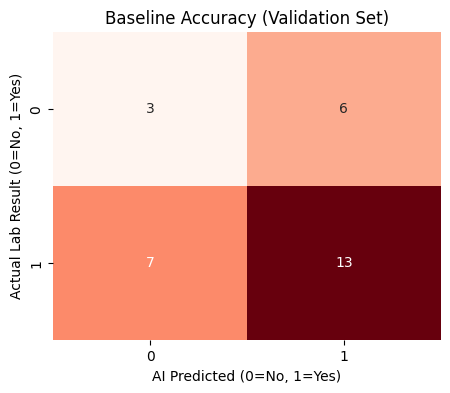

In [16]:
# plotting Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_val, predictions_val), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Baseline Accuracy (Validation Set)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()

This is a code given by Gemini to 'map' what characteristics were most used in the validation. This may be useful when adding new descriptors.

/var/folders/hp/w678cy2j2fvf_gn9ys7fr_r00000gn/T/ipykernel_95704/1510073726.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Importance', y='Feature', palette='viridis')


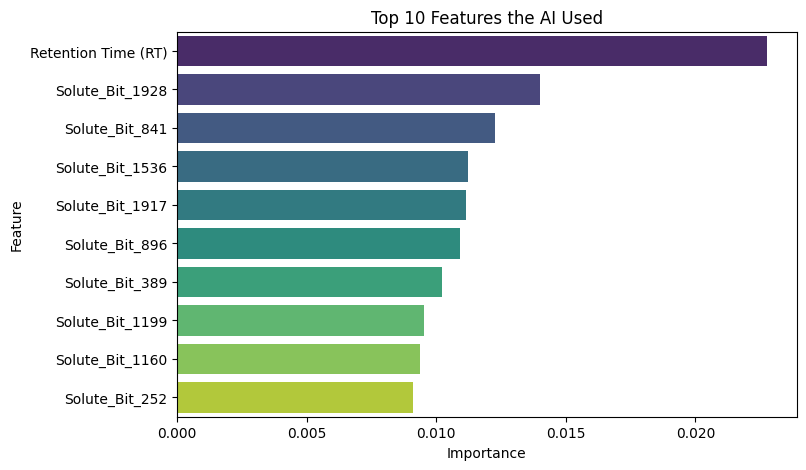

In [17]:
# Get the importance scores
importances = rf_baseline.feature_importances_

# Recreate the column names so we know what they are
solute_names = [f"Solute_Bit_{i}" for i in range(2048)]
rt_name = ["Retention Time (RT)"]
solvent_names = [f"Solvent_Bit_{i}" for i in range(2048)]
feature_names = solute_names + rt_name + solvent_names

# Create a DataFrame and sort it
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10 = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot it
plt.figure(figsize=(8, 5))
sns.barplot(data=top_10, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Features the AI Used')
plt.show()

Now this is only using one of the solvents available in the dictionary, this will be an attempt at introducing the model to new solvents.

In [2]:
cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------


In [3]:
print("Gathering data for all solvents...")
all_dfs = []
solvents_list = list(NMR_SOLVENTS.keys())

# looping on all solvents
for sol in solvents_list:
    if sol in cleaned_df.columns:
        df_temp = generate_ml_ready_file_fingerprint_solvent(cleaned_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs.append(df_temp)
        print(f" - {sol}: added {len(df_temp)} experiments.")


# .concat function that takes a list of separate DataFrames and smashes them on top of each other into one giant DataFrame
mega_df = pd.concat(all_dfs, ignore_index=True)
print(f"MEGA DATAFRAME CREATED: {len(mega_df)} TOTAL ROWS\n")



Gathering data for all solvents...


[10:59:22] DEPRECATION WARNING: please use MorganGenerator
[10:59:22] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerat

 - MeOH: added 144 experiments.


[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerator
[10:59:23] DEPRECATION WARNING: please use MorganGenerat

 - ACN: added 144 experiments.


[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerator
[10:59:24] DEPRECATION WARNING: please use MorganGenerat

 - DMSO: added 144 experiments.


[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerat

 - DCM: added 144 experiments.


[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:25] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerat

 - CHCl3: added 144 experiments.
MEGA DATAFRAME CREATED: 720 TOTAL ROWS



[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerator
[10:59:26] DEPRECATION WARNING: please use MorganGenerat

This cell is different, to uncover if the Morgan fingerprint actually hinders the accuracy the solvents will be coded differently: ***one-hot coded*** to be precise. It just means that for 5 solvents we'll make 5 independent codes. We suspect that somes solvents have too similar fingerprints....

In [8]:
print("Gathering data for all solvents...")
all_dfs = []
solvents_list = list(NMR_SOLVENTS.keys())

# looping on all solvents
for sol in solvents_list:
    if sol in cleaned_df.columns:
        df_temp = generate_ml_ready_file_onehot_solvent(cleaned_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs.append(df_temp)
        print(f" - {sol}: added {len(df_temp)} experiments.")


# .concat function that takes a list of separate DataFrames and smashes them on top of each other into one giant DataFrame
mega_df = pd.concat(all_dfs, ignore_index=True)
print(f"MEGA DATAFRAME CREATED: {len(mega_df)} TOTAL ROWS\n")

Gathering data for all solvents...


[16:05:45] DEPRECATION WARNING: please use MorganGenerator
[16:05:45] DEPRECATION WARNING: please use MorganGenerator
[16:05:45] DEPRECATION WARNING: please use MorganGenerator
[16:05:45] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerator
[16:05:46] DEPRECATION WARNING: please use MorganGenerat

 - MeOH: added 144 experiments.


[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerat

 - ACN: added 144 experiments.


[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerator
[16:05:47] DEPRECATION WARNING: please use MorganGenerat

 - DMSO: added 144 experiments.


[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerator
[16:05:48] DEPRECATION WARNING: please use MorganGenerat

 - DCM: added 144 experiments.


[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerat

 - CHCl3: added 144 experiments.
MEGA DATAFRAME CREATED: 720 TOTAL ROWS



[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator
[16:05:49] DEPRECATION WARNING: please use MorganGenerator


In [14]:
print(mega_df['Solvent'].iloc[500])

[0 0 0 1 0]


In [15]:
X_solute = np.vstack(mega_df['Sample Fingerprint'].values)  
X_rt = mega_df['RT'].values.reshape(-1, 1)           
X_solvent = np.vstack(mega_df['Solvent'].values)     

X = np.hstack((X_solute, X_rt, X_solvent))
y = mega_df['Soluble'].values
groups = mega_df['SMILES'].values # Why SMILES? it's to prevent a potential problem, when model will randomly select data as training it might not see that there's mol for MEOH and ACn and DMSO...
                                # this can falsify the precision of the model because it will not differentiate the solvents (it's not learning chemistry). SO by adding SMILES, we tell the code that
                                # if he encounters several similar SMILES to take them all into account in the training, that way in knows there's a difference between solvents.  
                                # generate_ml_ready_filehas been modified for this purpose.

In [16]:
print("Splitting data safely by Molecule...")

# splitting of the data in same proportions as before, GroupShuffleSplit model needed to shuffle as explained before
# first take out the 30% and keep training set
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups))

X_train, y_train, groups_temp = X[train_idx], y[train_idx], groups[temp_idx]
X_temp, y_temp = X[temp_idx], y[temp_idx]

# then separate validation and testing
gss2 = GroupShuffleSplit(n_splits=1, test_size=(1/3), random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print("\n--- Split Complete ---")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (20%)")
print(f"Testing Set:    {X_test.shape[0]} rows (10%)")

Splitting data safely by Molecule...

--- Split Complete ---
Training Set:   500 rows (70%)
Validation Set: 145 rows (20%)
Testing Set:    75 rows (10%)


In [17]:
rf_mega = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mega.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_val_pred = rf_mega.predict(X_val)

print("=========================================")
print("  MEGA MODEL EXAM RESULTS (VALIDATION SET)")
print("=========================================")
print(classification_report(y_val, y_val_pred))

  MEGA MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.61      0.20      0.31        54
           1       0.66      0.92      0.77        91

    accuracy                           0.66       145
   macro avg       0.64      0.56      0.54       145
weighted avg       0.64      0.66      0.60       145



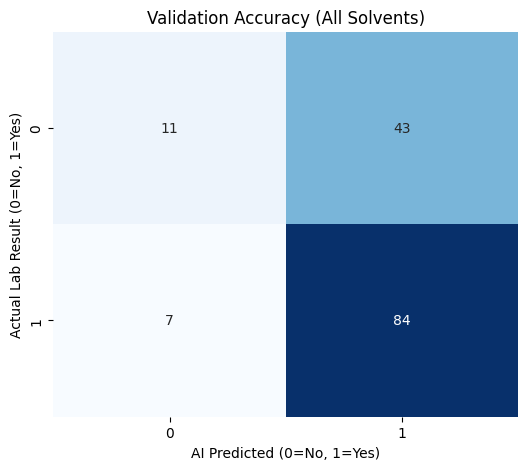

In [19]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Validation Accuracy (All Solvents)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()

A 1% increase in accuracy has been observed, not much but something at least... Let's add a new parameter to train on and analyze the outcome: **predicted logS** from Fastsolv. New function has been made in predictor_runner

First, we need to prepare the cleaned_df, make sure the predicted logS is in it (we've been working without it for a while).

In [2]:
cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')
# recalculating solubility
"""sol_matrix = solubility_file_matrix(cleaned_df, NMR_SOLVENTS)"""
sol_matrix= pd.read_excel('/Users/arthurbenard/Project 1B/data/Master_Solubility_Matrix.xlsx')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------


In [3]:
final_working_df = add_logs_to_df(cleaned_df, sol_matrix, NMR_SOLVENTS)

Successfully added 5 exact logS columns


In [4]:
print(final_working_df.columns.tolist())

['Column', 'Method', 'Sample Name', 'CAS ', 'RT', 'Signal', 'Matrix ID Name', 'MeOH', 'ACN', 'DMSO', 'DCM', 'CHCl3', 'solute_smiles', 'predicted_logS_MeOH', 'predicted_logS_ACN', 'predicted_logS_DMSO', 'predicted_logS_DCM', 'predicted_logS_CHCl3']


In [4]:
print("Gathering data for all solvents...")
all_dfs_v3 = []

for sol in NMR_SOLVENTS.keys():
    # since we are using cleaned_df, we just look for 'MeOH', 'ACN', etc.
    if sol in cleaned_df.columns:
        df_temp = generate_ml_file_with_logs(final_working_df, sol, NMR_SOLVENTS, smiles_to_fingerprint)
        all_dfs_v3.append(df_temp)
        print(f"Added {sol}: {len(df_temp)} rows")
    else:
        print(f"Skipped {sol}: Column not found")

# sticking everything together
mega_df_v3 = pd.concat(all_dfs_v3, ignore_index=True)
print(f"DataFrame built! Total Rows: {len(mega_df_v3)}")

Gathering data for all solvents...


[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerator
[11:12:17] DEPRECATION WARNING: please use MorganGenerat

Added MeOH: 144 rows


[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerator
[11:12:18] DEPRECATION WARNING: please use MorganGenerat

Added ACN: 144 rows


[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerator
[11:12:19] DEPRECATION WARNING: please use MorganGenerat

Added DMSO: 144 rows


[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerator
[11:12:20] DEPRECATION WARNING: please use MorganGenerat

Added DCM: 144 rows


[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerat

Added CHCl3: 144 rows
DataFrame built! Total Rows: 720


[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerator
[11:12:21] DEPRECATION WARNING: please use MorganGenerat

Some code to check if it was built correctly.

In [6]:
# 1. Check the overall shape and data types
print(f"Total Shape: {mega_df_v3.shape[0]} rows, {mega_df_v3.shape[1]} columns\n")
print("--- Data Types & Non-Null Counts ---")
print(mega_df_v3.info())

# 2. Check for any sneaky missing values
print("\n--- Missing Values ---")
print(mega_df_v3.isnull().sum())

# 3. Verify the 'Soluble' target is strictly 0s and 1s
print(f"\n--- Unique values in 'Soluble' column ---")
print(mega_df_v3['Soluble'].unique())

# 4. Verify the One-Hot array length (should be 5 if you have 5 solvents)
sample_array = mega_df_v3['Solvent'].iloc[0]
print(f"\n--- One-Hot Array Check ---")
print(f"Sample array: {sample_array}")
print(f"Array length: {len(sample_array)}")

# 5. Take a peek at the actual data (focusing on our new logS column!)
print("\n--- First 3 Rows ---")
display(mega_df_v3[['SMILES', 'RT', 'logS', 'Solvent', 'Soluble']].head(3))

print(mega_df_v3[['logS','Solvent']].iloc[145])

Total Shape: 720 rows, 6 columns

--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sample Fingerprint  720 non-null    object 
 1   RT                  720 non-null    float64
 2   logS                720 non-null    float64
 3   Solvent             720 non-null    object 
 4   Soluble             720 non-null    int64  
 5   SMILES              720 non-null    str    
dtypes: float64(2), int64(1), object(2), str(1)
memory usage: 57.1+ KB
None

--- Missing Values ---
Sample Fingerprint    0
RT                    0
logS                  0
Solvent               0
Soluble               0
SMILES                0
dtype: int64

--- Unique values in 'Soluble' column ---
[1 0]

--- One-Hot Array Check ---
Sample array: [1 0 0 0 0]
Array length: 5

--- First 3 Rows ---


,SMILES,RT,logS,Solvent,Soluble
0,CC(C1=CC=CC=C1)Br,5.607,0.594901,"[1, 0, 0, 0, 0]",1
1,C1C(CC(=O)NC1=O)CC(=O)O,1.146,-0.160339,"[1, 0, 0, 0, 0]",0
2,C1=CC=C(C=C1)COC(=O)NCC(=O)NCC(=O)O,4.021,-1.251555,"[1, 0, 0, 0, 0]",0


logS             -1.425989
Solvent    [0, 1, 0, 0, 0]
Name: 145, dtype: object


In [6]:
print("Unique values in the 'Soluble' column:")
print(mega_df_v3['Soluble'].value_counts(dropna=False))

Unique values in the 'Soluble' column:
Soluble
1    473
0    247
Name: count, dtype: int64


In [8]:
X_solute = np.vstack(mega_df_v3['Sample Fingerprint'].values)  
X_rt     = mega_df_v3['RT'].values.reshape(-1, 1)    
X_logs   = mega_df_v3['logS'].values.reshape(-1, 1)  # NEW reshaping like above line
X_solvent= np.vstack(mega_df_v3['Solvent'].values)

X_v3 = np.hstack((X_solute, X_rt, X_logs, X_solvent))
y_v3 = mega_df_v3['Soluble'].values
groups_v3 = mega_df_v3['SMILES'].values

print(f" Final matrix shape: {X_v3.shape}")

 Final matrix shape: (720, 2055)


Now that the final matrix is done, let's train.

In [9]:
print("Splitting data safely by Molecule...")

# splitting of the data in same proportions as before, GroupShuffleSplit model needed to shuffle as explained before
# first take out the 30% and keep training set
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X_v3, y_v3, groups_v3))

X_train, y_train, groups_temp = X_v3[train_idx], y_v3[train_idx], groups_v3[temp_idx]
X_temp, y_temp = X_v3[temp_idx], y_v3[temp_idx]

# then separate validation and testing
gss2 = GroupShuffleSplit(n_splits=1, test_size=(1/3), random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print("\n--- Split Complete ---")
print(f"Training Set:   {X_train.shape[0]} rows (70%)")
print(f"Validation Set: {X_val.shape[0]} rows (20%)")
print(f"Testing Set:    {X_test.shape[0]} rows (10%)")

Splitting data safely by Molecule...

--- Split Complete ---
Training Set:   500 rows (70%)
Validation Set: 145 rows (20%)
Testing Set:    75 rows (10%)


In [10]:
rf_mega = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mega.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
y_val_pred = rf_mega.predict(X_val)

print("=========================================")
print("  V3 MEGA MODEL EXAM RESULTS (VALIDATION SET)")
print("=========================================")
print(classification_report(y_val, y_val_pred))

  V3 MEGA MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.80      0.37      0.51        54
           1       0.72      0.95      0.82        91

    accuracy                           0.73       145
   macro avg       0.76      0.66      0.66       145
weighted avg       0.75      0.73      0.70       145



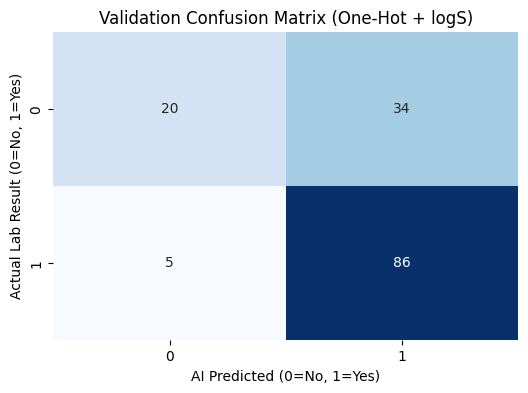

In [12]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Validation Confusion Matrix (One-Hot + logS)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()

This cell right under is part of the 'removing features from model' function I wrote. I'm testing out different things and saving them in files (removing ***A*** feature then removing ***SOME*** features).

In [12]:
df_results = run_ablation_study(mega_df_v3)

  AVAILABLE FEATURES TO REMOVE:
  - Sample Fingerprint
  - RT
  - logS
  - Solvent
  - None (Keep all features)

Removing [Sample Fingerprint] from model...
Matrix shape after removal: (720, 7)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_Sample_Fingerprint.txt




Removing [None] from model...
Matrix shape after removal: (720, 2055)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_None.txt


Removing [RT] from model...
Matrix shape after removal: (720, 2054)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_RT.txt


Removing [logS] from model...
Matrix shape after removal: (720, 2054)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_logS.txt


Removing [RT, logS] from model...
Matrix shape after removal: (720, 2055)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_RT,_logS.txt


Removing [Sample Fingerprint] from model...
Matrix shape after removal: (720, 7)
   -> Results saved to /Users/arthurbenard/Project 1B/src/analysis/model_analysis_results/ablation_results_no_Sample_Fingerprint.txt


Removing [Sampl

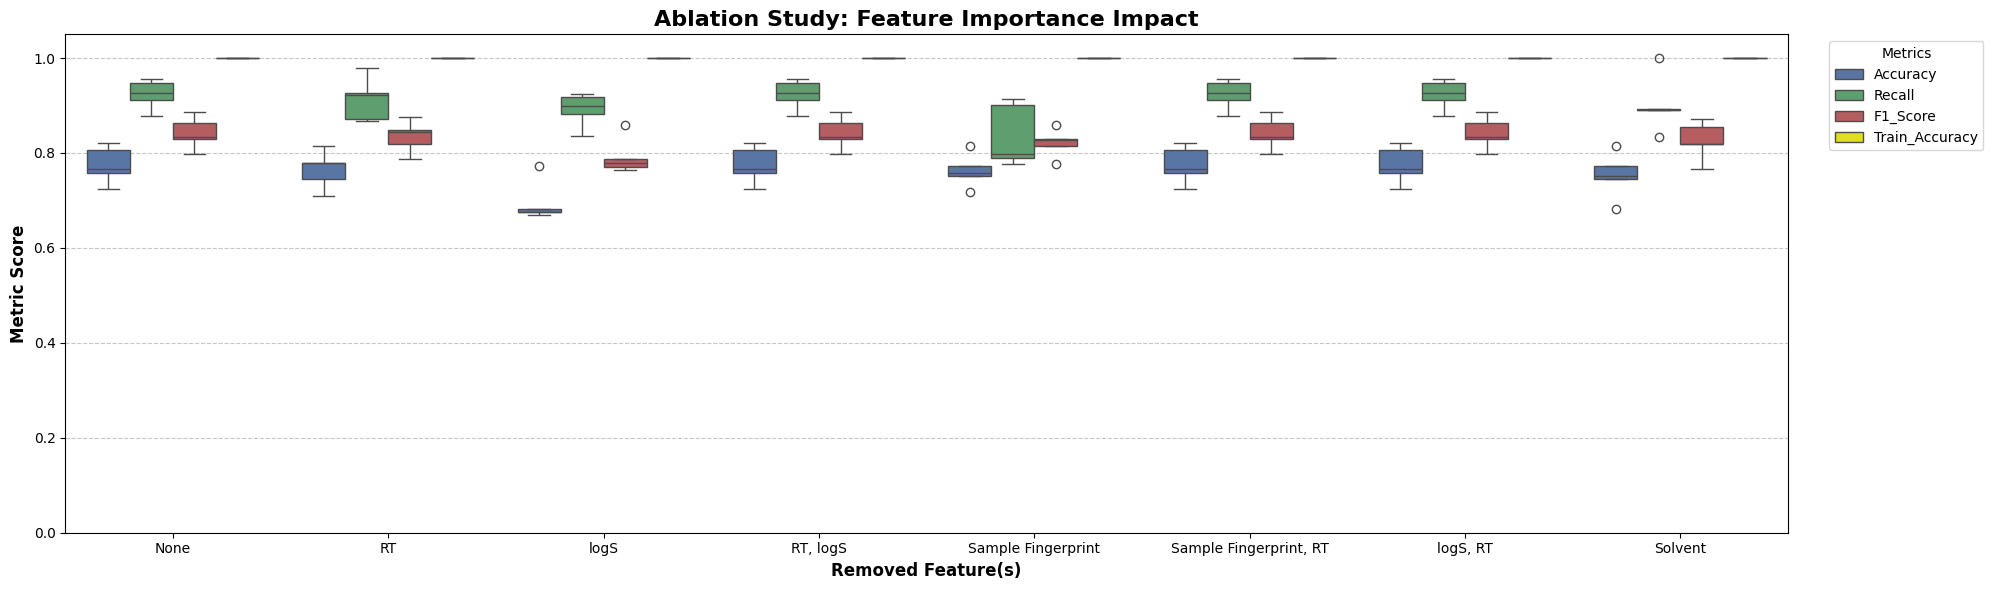

In [5]:
df_none = run_ablation_study(mega_df_v3, features_to_remove='None')
df_rt = run_ablation_study(mega_df_v3, features_to_remove='RT')
df_logs = run_ablation_study(mega_df_v3, features_to_remove='logS')
df_both = run_ablation_study(mega_df_v3, features_to_remove='RT, logS')
df_fp = run_ablation_study(mega_df_v3, features_to_remove='Sample Fingerprint')
df_fp_rt = run_ablation_study(mega_df_v3, features_to_remove='Sample Fingerprint, RT')
df_fp_logs = run_ablation_study(mega_df_v3, features_to_remove='logS, RT')
df_sol = run_ablation_study(mega_df_v3, features_to_remove='Solvent')

# Glue them together into one massive DataFrame
all_results_df = pd.concat([df_none, df_rt, df_logs, df_both, df_fp, df_fp_rt, df_fp_logs, df_sol], ignore_index=True)

plot_comparison(all_results_df)

In [6]:
print(all_results_df.columns)

Index(['Removed_Feature', 'Seed', 'Train_Accuracy', 'Accuracy', 'Precision',
       'Recall', 'F1_Score'],
      dtype='str')


Now that RT and logS have successfully been added to the training model, let's see if adding another parameter helps predict better: the **matrix ID**. Since there's only 7 different types of matrix IDs, I recommend using one-hot coding again. We can't use our current cleaning_array functions because this time we need the repeating data (they only differ by Matrix ID). To prevent complicating things we sould may